# Missing Data Handling and Stock Market Data Preprocessing

**Student ID:** IT25102978  
**Role:** Member 1   
**Individual technique:** Handling missing data and data validation  
**Objective:** Clean the global stock-market index dataset, present individual EDA evidence, create the next-day Up/Down target, perform a chronological train-validation-test split, and encode the `Index` field.

## 1. Upload the original dataset
Upload the original file named `Market.csv`.

In [1]:
from google.colab import files

uploaded = files.upload()

Saving Market.csv to Market.csv


## 2. Import libraries and inspect the raw dataset

In [2]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import zipfile

charts_dir = Path("results/eda_visualizations")
outputs_dir = Path("results/outputs")
charts_dir.mkdir(parents=True, exist_ok=True)
outputs_dir.mkdir(parents=True, exist_ok=True)

df = pd.read_csv("Market.csv")

print("First five records:")
display(df.head())

print("\nOriginal shape:", df.shape)

print("\nDataset information:")
df.info()

print("\nMissing values by column:")
print(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())
print("Number of market indices:", df["Index"].nunique())

First five records:


,Index,Date,Open,High,Low,Close,Adj Close,Volume
0,NYA,12/31/1965,528.690002,528.690002,528.690002,528.690002,528.690002,0.0
1,NYA,1/3/1966,527.210022,527.210022,527.210022,527.210022,527.210022,0.0
2,NYA,1/4/1966,527.840027,527.840027,527.840027,527.840027,527.840027,0.0
3,NYA,1/5/1966,531.119995,531.119995,531.119995,531.119995,531.119995,0.0
4,NYA,1/6/1966,532.070007,532.070007,532.070007,532.070007,532.070007,0.0



Original shape: (112457, 8)

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112457 entries, 0 to 112456
Data columns (total 8 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   Index      112457 non-null  object 
 1   Date       112457 non-null  object 
 2   Open       110253 non-null  float64
 3   High       110252 non-null  float64
 4   Low        110251 non-null  float64
 5   Close      110250 non-null  float64
 6   Adj Close  110244 non-null  float64
 7   Volume     110253 non-null  float64
dtypes: float64(6), object(2)
memory usage: 6.9+ MB

Missing values by column:
Index           0
Date            0
Open         2204
High         2205
Low          2206
Close        2207
Adj Close    2213
Volume       2204
dtype: int64

Duplicate rows: 0
Number of market indices: 14


## 2.1 Individual EDA visualization - missing values
This chart is created before cleaning. It shows which columns contain missing data and provides the required individual EDA visualization for the Progress Review I viva.

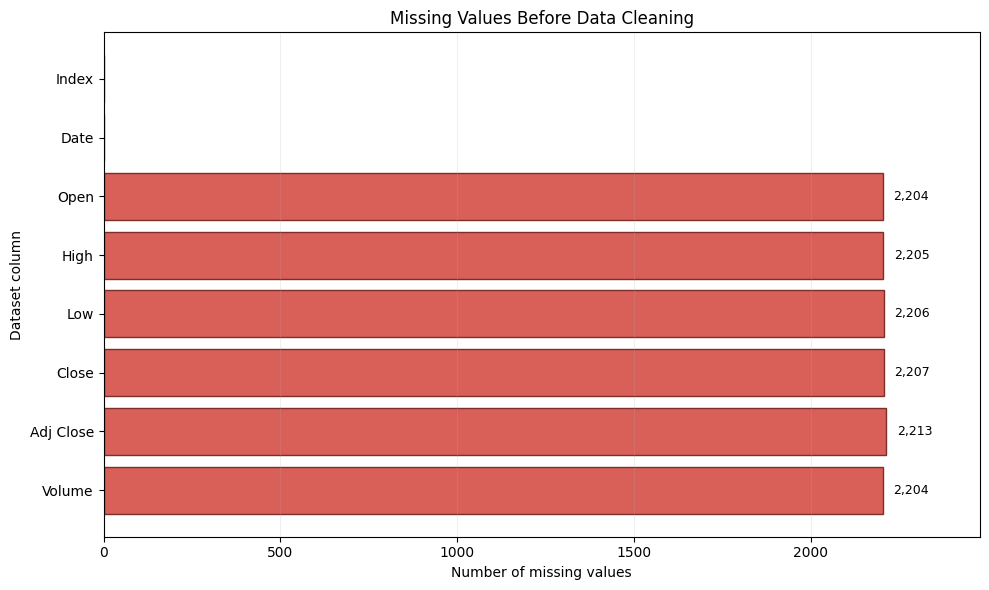

Interpretation: Six numerical columns contain missing values.
The highest column-level count is in Adj Close.


In [3]:
missing_before = df.isnull().sum()
y = np.arange(len(missing_before))

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(
    y, missing_before.values, color="#D95F59",
    edgecolor="#7D2E2A", label="Before cleaning"
)
ax.set_yticks(y, missing_before.index)
ax.invert_yaxis()
ax.set_xlabel("Number of missing values")
ax.set_ylabel("Dataset column")
ax.set_title("Missing Values Before Data Cleaning")
ax.set_xlim(0, max(missing_before.max() * 1.12, 1))
ax.grid(axis="x", alpha=0.2)

for bar in bars:
    value = int(bar.get_width())
    if value > 0:
        ax.text(
            value + 30, bar.get_y() + bar.get_height() / 2,
            f"{value:,}", va="center", fontsize=9
        )

fig.tight_layout()
missing_chart_path = charts_dir / "IT25102978_missing_values.png"
fig.savefig(missing_chart_path, dpi=300, bbox_inches="tight")
plt.show()

print("Interpretation: Six numerical columns contain missing values.")
print("The highest column-level count is in Adj Close.")

## 3. Convert dates and handle duplicates and missing values
Rows missing any required modelling value are removed. This dataset contains no duplicate rows.

In [4]:
df["Date"] = pd.to_datetime(df["Date"], errors="coerce")

required_columns = [
    "Index", "Date", "Open", "High",
    "Low", "Close", "Adj Close", "Volume"
]

rows_with_missing = df[required_columns].isnull().any(axis=1).sum()
missing_percentage = rows_with_missing / len(df) * 100
duplicate_count = df.duplicated().sum()

print("Rows containing missing values:", rows_with_missing)
print(f"Missing-row percentage: {missing_percentage:.2f}%")
print("Duplicate rows:", duplicate_count)

df = df.drop_duplicates()
df = df.dropna(subset=required_columns).copy()

print("Shape after handling missing values and duplicates:", df.shape)

Rows containing missing values: 2219
Missing-row percentage: 1.97%
Duplicate rows: 0
Shape after handling missing values and duplicates: (110238, 8)


## 4. Detect and remove invalid financial records
The checks identify non-positive prices, negative volume, and inconsistent OHLC values. Zero volume is allowed because some indices do not consistently report volume.

In [5]:
invalid_rows = (
    (df["Open"] <= 0) |
    (df["High"] <= 0) |
    (df["Low"] <= 0) |
    (df["Close"] <= 0) |
    (df["Adj Close"] <= 0) |
    (df["Volume"] < 0) |
    (df["High"] < df["Low"]) |
    (df["High"] < df[["Open", "Close"]].max(axis=1)) |
    (df["Low"] > df[["Open", "Close"]].min(axis=1))
)

print("Number of invalid records:", invalid_rows.sum())
print("\nInvalid records:")
display(df.loc[invalid_rows])

df = df.loc[~invalid_rows].copy()

print("Shape after removing invalid records:", df.shape)

Number of invalid records: 1

Invalid records:


,Index,Date,Open,High,Low,Close,Adj Close,Volume
852,NYA,1969-06-30,5722.359985,572.359985,572.359985,572.359985,572.359985,0.0


Shape after removing invalid records: (110237, 8)


## 5. Handle zero-volume records and create the prediction target
`Volume_Available` equals 1 when volume is reported and 0 otherwise. The target is 1 when the next closing price is higher than the current closing price, and 0 otherwise. Target creation is performed separately within each market index.

In [6]:
zero_volume_count = (df["Volume"] == 0).sum()
print("Zero-volume records before target creation:", zero_volume_count)

df["Volume_Available"] = (df["Volume"] > 0).astype(int)

df = df.sort_values(["Index", "Date"]).reset_index(drop=True)

df["Next_Close"] = df.groupby("Index")["Close"].shift(-1)
df["Target_Date"] = df.groupby("Index")["Date"].shift(-1)

df = df.dropna(subset=["Next_Close", "Target_Date"]).copy()
df["Target"] = (df["Next_Close"] > df["Close"]).astype(int)

cleaned_df = df.drop(columns=["Next_Close", "Target_Date"]).copy()

print("Final cleaned shape:", cleaned_df.shape)
print("\nTarget counts:")
print(cleaned_df["Target"].value_counts())

print("\nTarget percentages:")
print(cleaned_df["Target"].value_counts(normalize=True).mul(100).round(2))

Zero-volume records before target creation: 42077
Final cleaned shape: (110223, 10)

Target counts:
Target
1    58508
0    51715
Name: count, dtype: int64

Target percentages:
Target
1    53.08
0    46.92
Name: proportion, dtype: float64


## 5.1 Additional EDA visualization - target distribution
This chart checks whether the Up and Down target classes are balanced.

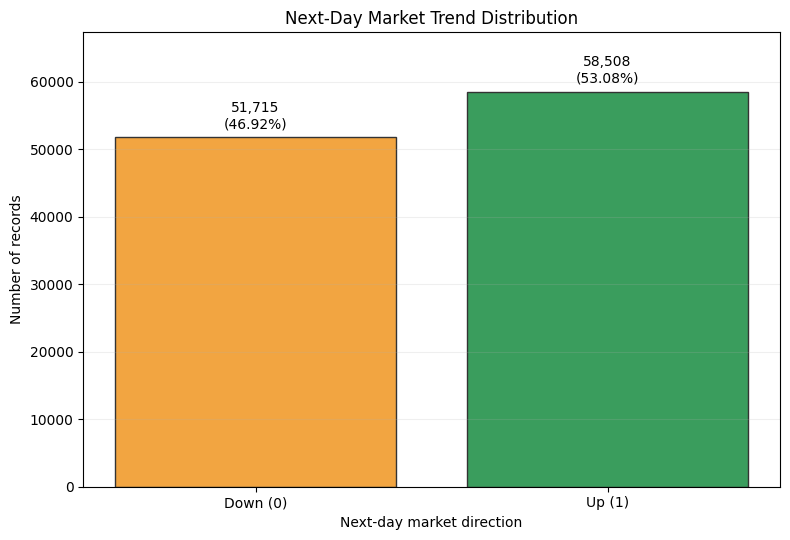

Interpretation: The target is reasonably balanced.
Up is the majority class at approximately 53.08%.


In [7]:
target_counts = cleaned_df["Target"].value_counts().reindex([0, 1])
labels = ["Down (0)", "Up (1)"]

fig, ax = plt.subplots(figsize=(8, 5.5))
bars = ax.bar(
    labels, target_counts.values,
    color=["#F2A541", "#3A9D5D"], edgecolor="#333333"
)
ax.set_title("Next-Day Market Trend Distribution")
ax.set_xlabel("Next-day market direction")
ax.set_ylabel("Number of records")
ax.grid(axis="y", alpha=0.2)

total = int(target_counts.sum())
for bar, value in zip(bars, target_counts.values):
    percentage = value / total * 100
    ax.text(
        bar.get_x() + bar.get_width() / 2, value + total * 0.008,
        f"{value:,}\n({percentage:.2f}%)",
        ha="center", va="bottom", fontsize=10
    )

ax.set_ylim(0, target_counts.max() * 1.15)
fig.tight_layout()
target_chart_path = charts_dir / "IT25102978_target_distribution.png"
fig.savefig(target_chart_path, dpi=300, bbox_inches="tight")
plt.show()

print("Interpretation: The target is reasonably balanced.")
print("Up is the majority class at approximately 53.08%.")

## 6. Validate the cleaned dataset
These checks confirm that the cleaned output contains no missing values, duplicates, invalid volume, or leakage columns.

In [8]:
print("Final shape:", cleaned_df.shape)
print("\nFinal columns:")
print(cleaned_df.columns.tolist())
print("\nMissing values:")
print(cleaned_df.isnull().sum())
print("\nDuplicate rows:", cleaned_df.duplicated().sum())
print("Invalid dates:", cleaned_df["Date"].isnull().sum())
print("Negative-volume records:", (cleaned_df["Volume"] < 0).sum())
print("Zero-volume records:", (cleaned_df["Volume"] == 0).sum())
print("\nVolume flag counts:")
print(cleaned_df["Volume_Available"].value_counts())
print("\nTarget distribution:")
print(cleaned_df["Target"].value_counts())

assert cleaned_df.shape[1] == 10
assert cleaned_df.isnull().sum().sum() == 0
assert cleaned_df.duplicated().sum() == 0
assert (cleaned_df["Volume"] < 0).sum() == 0
assert set(cleaned_df["Target"].unique()) == {0, 1}
assert "Next_Close" not in cleaned_df.columns
assert "Target_Date" not in cleaned_df.columns

print("\nAll preprocessing validation tests passed!")

Final shape: (110223, 10)

Final columns:
['Index', 'Date', 'Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume', 'Volume_Available', 'Target']

Missing values:
Index               0
Date                0
Open                0
High                0
Low                 0
Close               0
Adj Close           0
Volume              0
Volume_Available    0
Target              0
dtype: int64

Duplicate rows: 0
Invalid dates: 0
Negative-volume records: 0
Zero-volume records: 42075

Volume flag counts:
Volume_Available
1    68148
0    42075
Name: count, dtype: int64

Target distribution:
Target
1    58508
0    51715
Name: count, dtype: int64

All preprocessing validation tests passed!


## 7. Perform a chronological 70%-15%-15% split
Each market index is split separately in chronological order. This ensures that all 14 indices are represented in training, validation, and testing while preventing future observations within an index from entering its training period. No random shuffling is used.

In [9]:
train_parts = []
validation_parts = []
test_parts = []

for index_name, index_data in df.groupby("Index", sort=False):
    index_data = index_data.sort_values("Target_Date").copy()
    number_of_rows = len(index_data)

    train_end = int(number_of_rows * 0.70)
    validation_end = int(number_of_rows * 0.85)

    train_part = index_data.iloc[:train_end].copy()
    validation_part = index_data.iloc[train_end:validation_end].copy()
    test_part = index_data.iloc[validation_end:].copy()

    assert train_part["Target_Date"].max() < validation_part["Target_Date"].min()
    assert validation_part["Target_Date"].max() < test_part["Target_Date"].min()

    train_parts.append(train_part)
    validation_parts.append(validation_part)
    test_parts.append(test_part)

train_source = pd.concat(train_parts, ignore_index=True)
validation_source = pd.concat(validation_parts, ignore_index=True)
test_source = pd.concat(test_parts, ignore_index=True)

columns_to_remove = ["Next_Close", "Target_Date"]
train_df = train_source.drop(columns=columns_to_remove)
validation_df = validation_source.drop(columns=columns_to_remove)
test_df = test_source.drop(columns=columns_to_remove)

print("Training shape:", train_df.shape)
print("Validation shape:", validation_df.shape)
print("Testing shape:", test_df.shape)

print("\nIndices in training:", train_df["Index"].nunique())
print("Indices in validation:", validation_df["Index"].nunique())
print("Indices in testing:", test_df["Index"].nunique())

split_summary = pd.DataFrame({
    "Dataset": ["Training", "Validation", "Testing"],
    "Rows": [len(train_df), len(validation_df), len(test_df)],
    "Percentage": [
        len(train_df) / len(cleaned_df) * 100,
        len(validation_df) / len(cleaned_df) * 100,
        len(test_df) / len(cleaned_df) * 100
    ]
})
split_summary["Percentage"] = split_summary["Percentage"].round(2)
display(split_summary)

Training shape: (77150, 10)
Validation shape: (16534, 10)
Testing shape: (16539, 10)

Indices in training: 14
Indices in validation: 14
Indices in testing: 14


,Dataset,Rows,Percentage
0,Training,77150,69.99
1,Validation,16534,15.00
2,Testing,16539,15.01


## 8. Encode the Index field
One-hot encoding converts the categorical market index into numeric indicator columns. Validation and test columns are aligned with the training columns. Scaling is deliberately excluded because any scaler must be fitted only by the model member using the training data.

In [10]:
train_encoded = pd.get_dummies(
    train_df, columns=["Index"], prefix="Index", dtype=int
)
validation_encoded = pd.get_dummies(
    validation_df, columns=["Index"], prefix="Index", dtype=int
)
test_encoded = pd.get_dummies(
    test_df, columns=["Index"], prefix="Index", dtype=int
)

validation_encoded = validation_encoded.reindex(
    columns=train_encoded.columns, fill_value=0
)
test_encoded = test_encoded.reindex(
    columns=train_encoded.columns, fill_value=0
)

index_columns = [
    column for column in train_encoded.columns
    if column.startswith("Index_")
]

print("Encoded training shape:", train_encoded.shape)
print("Encoded validation shape:", validation_encoded.shape)
print("Encoded testing shape:", test_encoded.shape)
print("\nEncoded Index columns:")
print(index_columns)

Encoded training shape: (77150, 23)
Encoded validation shape: (16534, 23)
Encoded testing shape: (16539, 23)

Encoded Index columns:
['Index_000001.SS', 'Index_399001.SZ', 'Index_GDAXI', 'Index_GSPTSE', 'Index_HSI', 'Index_IXIC', 'Index_J203.JO', 'Index_KS11', 'Index_N100', 'Index_N225', 'Index_NSEI', 'Index_NYA', 'Index_SSMI', 'Index_TWII']


## 9. Verify the split and encoded datasets

In [11]:
assert train_encoded.isnull().sum().sum() == 0
assert validation_encoded.isnull().sum().sum() == 0
assert test_encoded.isnull().sum().sum() == 0
assert list(train_encoded.columns) == list(validation_encoded.columns)
assert list(train_encoded.columns) == list(test_encoded.columns)
assert len(train_encoded) + len(validation_encoded) + len(test_encoded) == len(cleaned_df)

print("Chronological split verified!")
print("All encoded datasets contain matching columns!")
print("All cleaned observations were assigned to exactly one split!")

Chronological split verified!
All encoded datasets contain matching columns!
All cleaned observations were assigned to exactly one split!


## 10. Save and download the deliverables
The general cleaned file retains the original `Index` field for EDA. The three model files contain one-hot encoded index columns and follow the chronological split.

In [13]:
cleaned_path = outputs_dir / "cleaned_market_data.csv"
train_path = outputs_dir / "train_data.csv"
validation_path = outputs_dir / "validation_data.csv"
test_path = outputs_dir / "test_data.csv"

cleaned_df.to_csv(cleaned_path, index=False)
train_encoded.to_csv(train_path, index=False)
validation_encoded.to_csv(validation_path, index=False)
test_encoded.to_csv(test_path, index=False)

output_files = [
    cleaned_path, train_path, validation_path, test_path,
    missing_chart_path, target_chart_path
]

zip_filename = "IT25102978_Preprocessed_Data.zip"

with zipfile.ZipFile(zip_filename, "w", zipfile.ZIP_DEFLATED) as zip_file:
    for filename in output_files:
        zip_file.write(filename, arcname=str(filename))

print("Files successfully saved:")
for filename in output_files:
    print("-", filename)

files.download(zip_filename)

Files successfully saved:
- results/outputs/cleaned_market_data.csv
- results/outputs/train_data.csv
- results/outputs/validation_data.csv
- results/outputs/test_data.csv
- results/eda_visualizations/IT25102978_missing_values.png
- results/eda_visualizations/IT25102978_target_distribution.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>